In [78]:
import os
import sys
from pathlib import Path
funcdir = os.getcwd()

import pprint
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import ticker
import matplotlib.gridspec as gridspec

from tqdm import tqdm

from numba import jit #We will attempt to precompile some routines
import concurrent.futures
# Import tpy5_inputs_class from transitPy5
from pytfit5.transitPy5 import tpy5_inputs_class
from pytfit5 import period_validation as pval
from pytfit5 import normalisation as norm

# Importing tls functionality
sys.path.insert(0, f'{funcdir}')
from tls.transitleastsquares import main as tlsm

# Backward compatibility alias (deprecated)
gbls_inputs_class = tpy5_inputs_class

#Constants
G       = 6.674e-11           # N m^2 kg^-2  Gravitation constant
Rsun    = 696265.0e0*1000.0e0 # m  radius of Sun
Msun    = 1.9891e30           # kg  mass of Sun
pifac   = 1.083852140278e0    # (2pi)^(2/3)/pi
day2sec = 86400.0             # seconds in a day
onehour = 1.0/24.0            # one hour convected to day.
kepfac = (2*np.pi)**2/G       # used below in the tls calculation

class gbls_ans_class:
    def __init__(self):
        self.epo      = 0.0
        self.bper     = 0.0
        self.rawper   = 0.0
        self.bpower   = -1
        self.snr      = -1
        self.tdur     = 8.0
        self.depth    = 1.0
        self.periods  = None  # Full period array (if return_spectrum=True)
        self.power    = None  # Full power array (if return_spectrum=True)
        self.freqs    = None  # Full frequency array (if return_spectrum=True)
        self.SR       = None # The signal residuals which apply for TLS

## COMMON FUNCTIONS USED ACROSS BOTH SEARCHES
def readfile(filename):

    itime1 = 1765.5/86400.0 #Kepler integration time
    
    i=0
    #data=[] #Create an empty list
    time  = []
    flux  = []
    ferr  = []
    # itime = []
    f=open(filename)
    for line in f:
        if i>0:
            line = line.strip() #removes line breaks 
            #columns = line.split() #break into columns based on a delimiter.  This example is for spaces
            columns = line.split() #if your data is seperated by commas, use this. 
            #data.append([float(r) for r in columns]) #Append 
            time.append(float(columns[0]))
            flux.append(float(columns[1]))
            ferr.append(float(columns[2]))
            # itime.append(itime1)
        i+=1
    f.close()
    
    #data = np.array(data)
    time = np.array(time)
    flux = np.array(flux)
    ferr = np.array(ferr)
    # itime = np.array(itime)
    
    return time, flux, ferr #, itime

def prep_timeflux(tpy5_inputs, time, flux, ferr=None, central=True):
    '''
    Assigns the lcdir and filename if neccessary to prevent errors.
    Ensures time and flux are loaded if not provided. Pre-processing
    which is to find the minimum time and to subtract the median of flux.
    '''

    if tpy5_inputs.lcdir != "":
        filename = tpy5_inputs.lcdir + "/" + tpy5_inputs.filename
    if (time.shape[0] < 2) or (flux.shape[0] < 2):
        time, flux, ferr = readfile(filename)

    if not central:
        return time, flux, ferr
        
    tpy5_inputs.mintime = np.min(time)
    time = time - tpy5_inputs.mintime 
    flux = flux - np.median(flux)

    return filename, time, flux, ferr


## FOR THE PERIODIC SEARCH ONLY
@jit(nopython=True)
def nyquest_cpu(time):

    dt = np.zeros((time.shape[0]))
    
    for i in range(time.shape[0]-1):
        dt[i] = time[i+1] - time[i]

    mode = np.median(dt)
    nyq=1.0/(2.0*mode)

    return nyq

@jit(nopython=True)
def qfunc_cpu(f, Mstar, Rstar):
    '''
    Calculates optimal phase for circular orbit
    '''

    fsec = f/day2sec #Convert from c/d to c/sec 
    q = pifac * Rstar * Rsun / (G * Mstar * Msun)**(1.0/3.0) * fsec**(2.0/3.0)
    return q

@jit(nopython=True)
def calc_nsteps_cpu(Mstar, Rstar, freq1, freq2, nyq, ofac, npt, df0, nb, minbin):
    '''pre-calculate the number of steps to sweep the requested frequency range using optimum steping
    '''

    #Initialize counters
    f = freq1
    nstep = 0

    while(f<freq2):
        nstep+=1
        q = qfunc_cpu(f, Mstar, Rstar) #calculate shift to optimally sample based on expected transit duration
        df = q * df0 #estimate next frequency step based on optimum q
        f = f + df   #next frequency to scan

    return nstep
    
@jit(nopython=True)
def calc_freqs_cpu(nstep, Mstar, Rstar, freq1, freq2, nyq, ofac, npt, df0, nb, minbin):
    '''pre-calculate the number of steps to sweep the requested frequency range using optimum steping
    '''

    #Initialize arrays
    freqs = np.zeros((nstep))
    qs    = np.zeros((nstep))
    kmis  = np.zeros((3, nstep), dtype = np.int32) # kmi = 0, kma = 1, kkmi = 2
    
    #Initialize counters
    f = freq1
    i = 0
    # freqs[0] = f
    # qs[0]    = qfunc_cpu(f, Mstar, Rstar)

    while(f<freq2):
        qs[i] = qfunc_cpu(f, Mstar, Rstar) #calculate shift to optimally sample based on expected transit duration
        df = qs[i] * df0 #estimate next frequency step based on optimum q
        freqs[i] = f
        
        i += 1 #increase counter
        f = f + df   #next frequency to scan
    return freqs

@jit(nopython=True)
def bls_kernel_single(freq, time, flux, nb, Rstar, Mstar):
    """
    BLS kernel optimized for single event searches (Period > Duration).
    """
    # Explicitly cast nb to int for array creation
    nb = int(nb)
    npt = time.shape[0]
    
    # Duration of the dataset (Assuming time starts at 0, or is shifted)
    duration = time[npt-1]
    
    if duration <= 0:
        return 0.0, 0, 0

    nbm1 = int(nb - 1)
    
    # No buffer for wrapping needed
    ibi = np.zeros(nb, dtype=np.int32)
    y = np.zeros(nb, dtype=np.float64)
    
    # Bin the data: Map 0..duration to 0..nb
    # scale factor to convert time to bin index
    scale = nbm1 / duration
    
    for i in range(npt):
        # Map time[i] directly to a bin
        j = int(time[i] * scale)
        if j < nb:
            ibi[j] += 1
            y[j] += flux[i]
            
    # Calculate search parameters based on physics
    fsec = freq / day2sec
    q = pifac * Rstar * Rsun / (G * Mstar * Msun)**(1.0/3.0) * fsec**(2.0/3.0)
    
    # Calculate ratio of Period to Duration: P / T_dur = (1/f) / duration
    # This scales the duty cycle 'q' (fraction of Period) to fraction of the Array (Duration)
    pd_ratio = (1.0 / freq) / duration
    
    # Define limits for transit duration
    qmi = q / 2.0
    if qmi < onehour*freq/2:
        qmi = onehour*freq/2
        
    qma = q * 2.0
    if qma > 0.25:
        qma = 0.25
        
    if qmi > qma:
        qma = qmi * 2.0
        if qma > 0.4:
            qma = 0.4
            
    # Scale q limits (fraction of Period) to bin counts over the Duration
    # bins = q * (Period/Duration) * nb
    kmi = int(qmi * pd_ratio * nb)
    if kmi < 1: kmi = 1
    
    kma = int(qma * pd_ratio * nb) + 1
    if kma > nb: kma = nb
    
    # Minimum points in transit check
    kkmi = int(npt * qmi * pd_ratio)
    if kkmi < 5: kkmi = 5
    
    p = 0.0
    jn1 = 0
    jn2 = 0
    
    # Search loop (Linear scan, no wrapping)
    # i is start bin, j is end bin
    for i in range(nb):
        s = 0.0
        k = 0
        kk = 0
        
        # Determine max end index (clamped to nb)
        jmax = i + kma + 1
        if jmax > nb: jmax = nb
        
        for j in range(i, jmax):
            k += 1          # width in bins
            kk += ibi[j]    # count of points in bin j
            s += y[j]       # sum of flux in bin j
            
            # Check conditions
            if k > kmi and kk > kkmi:
                dfac = kk * (npt - kk)
                if dfac > 0:
                    pow1 = s*s / dfac
                    if pow1 > p:
                        p = pow1
                        jn1 = i
                        jn2 = j
                        
    return p, jn1, jn2

def compute_bls_kernel(iarg, freqs, time, flux, nb, Rstar, Mstar, ndiv):
    
    p = np.zeros((ndiv))
    jn1 = np.zeros((ndiv), dtype = np.int32)
    jn2 = np.zeros((ndiv), dtype = np.int32)
    
    # Calculate duration once
    duration = time[-1] - time[0] 

    j = 0
    for i in iarg:
        # Check if Period > Duration
        if (1.0 / freqs[i]) > duration:
            p[j], jn1[j], jn2[j] = bls_kernel_single(freqs[i], time, flux, nb, Rstar, Mstar)
        else:
            p[j], jn1[j], jn2[j] = bls_kernel(freqs[i], time, flux, nb, Rstar, Mstar)
        j += 1
        
    return p, jn1, jn2

@jit(nopython=True)
def bls_kernel(freq, time, flux, nb, Rstar, Mstar):

    npt = time.shape[0]

    nb2  = int(2 * nb)
    nbm1 = int(nb - 1)
    nb   = int(nb)

    ibi = np.zeros((nb2), dtype=np.int32)
    y   = np.zeros((nb2), dtype=np.float64)
    
    # Initialize return values to safe defaults
    p = 0.0
    jn1 = 0
    jn2 = 0

    for i in range(npt):

        phase = time[i]*freq - int(time[i]*freq)
        j = int(phase * nbm1)

        ibi[j] += 1
        y[j]   += flux[i]

    #duplicate array
    for i in range(nb):
        ibi[i+nb] = ibi[i]
        y[i+nb]   = y[i]

    fsec = freq / day2sec
    q = pifac * Rstar*Rsun / (G*Mstar*Msun)**(1.0/3.0) * fsec**(2.0/3.0)

    qmi = q / 2.0
    if qmi < onehour*freq/2:
        qmi = onehour*freq/2

    qma = q * 2.0
    if qma > 0.25:
        qma = 0.25

    if qmi > qma:
        qma = qmi * 2.0
        if qma > 0.4:
            qma = 0.4

    kmi = int(qmi * nb)
    if kmi < 1:
        kmi = 1
    kma = int(qma * nb) + 1
    kkmi = int(npt * qmi)
    if kkmi < 5: #minbin
        kkmi = 5
    nbkma = nb + kma

    for i in range(nb):
        s = 0.0
        k = 0
        kk = 0
        nb2 = i + kma + 1

        for j in range(i, nb2):
            k  = k + 1
            kk = kk + ibi[j]
            s  = s  + y[j]

            if k > kmi and kk > kkmi:
                dfac = (kk * (npt - kk)) #const[1] = npt
                if dfac > 0 :
                    pow1 = s*s / dfac

                    if pow1 > p:
                        p = pow1
                        jn1 = i
                        jn2 = j        
    
    return p, jn1, jn2

@jit(nopython=True)
def bls_stats(epo, period, tdur, npt, time, flux):
    # Import necessary libraries if not already imported (e.g., NumPy)

    f   = np.zeros((npt))
    fin = np.zeros((npt))

    tdurfac = 0.5
    
    ph1 = 0.75 - tdurfac * tdur / period
    if ph1 < 0.5:
        ph1 = 0.5
    
    ph2 = 0.75 + tdurfac * tdur / period
    if ph2 > 1.0:
        ph2 = 1.0
    
    toff = 0.75 - (epo / period - int(epo /period))
    if toff < 0.0:
        toff += 1
    
    k = 0  # number of data points out of transit
    kin = 0  # number of data points in transit

    for i in range(npt):
        phase = time[i] / period - int(time[i] / period) + toff
        
        if phase < 0.0:
            phase += 1.0
        elif phase > 1.0:
            phase -= 1.0
        
        if (phase < ph1) or (phase > ph2):
            k += 1
            # Update the out-of-transit flux array with this value
            f[k] = flux[i]
        else:
            kin += 1
            fin[kin] = flux[i]
    
    if k > 3:
        # Calculate standard deviation of out-of-transit data
        std = np.std(f[:k])
        fmean = np.mean(f[:k])
    else:
        fmean = 0.0
        std = 0.0
    
    if kin > 1:
        # Sort in-transit flux array and get median
        sorted_fin = np.sort(fin[:kin])
        depth = -sorted_fin[kin // 2] + fmean
    else:
        depth = fmean
    
    snr = 0.0

    if k > 3 and kin > 1 and std > 0.0:
        snr = depth / std * np.sqrt(kin)
    
    return fmean, std, depth, snr

def calc_eph(p, jn1, jn2, npt, time, flux, freqs, ofac, nstep, nb, mintime, Keptime, Mstar, Rstar, normalize_mode="iterative_baseline", oneoverf_correction=False, oneoverf_extrapolate=True, oneoverf_threshold=None):

    periods = 1/freqs # periods (days)
    
    # Estimate a data-driven, duty-cycle informed median filter width.
    # Falls back to a small odd kernel if estimation fails.
    width = norm._estimate_medfilt_width(freqs, time, Mstar, Rstar, max_width_bins=nstep-1, \
                            alpha=4*ofac, min_width=norm.nine_if_even(int(max(5, ofac*4))))

    sqrtp = np.sqrt(p)
    # Sanitize: replace NaN/Inf with very negative values so they don't dominate sort
    rawpower = np.where(np.isfinite(sqrtp), sqrtp, -1e30)
    rawsort = np.argsort(rawpower)
    rawper = periods[rawsort[-1]] 
    eps = 1e-12
    
    # Handle pure BLS case first (no processing needed)
    if normalize_mode == "none" and not oneoverf_correction:
        # Pure BLS spectrum with no baseline correction or normalization
        power = rawpower
        psort = rawsort
        bper = rawper

    else: # For all other cases, we need to compute baseline and/or normalization
        if normalize_mode == "none" and oneoverf_correction:
            # Baseline correction but no normalization
            # Use iterative baseline to avoid suppressing strong peaks
            baseline, _ = norm._iterative_baseline(sqrtp, width, sigma_thresh=3.0, max_iter=3)
            # Apply extrapolation if enabled
            if oneoverf_extrapolate:
                baseline = norm._extrapolate_baseline(baseline, freqs, time, width, threshold=oneoverf_threshold)
            residual = sqrtp - baseline
            power = residual
        elif normalize_mode == "iterative_baseline":
            # Iteratively identify continuum by clipping strong peaks
            # This is more robust for high-SNR signals that would bias standard methods
            if oneoverf_correction:
                # Apply baseline subtraction
                iter_baseline, peak_mask = norm._iterative_baseline(sqrtp, width, sigma_thresh=3.0, max_iter=3)
                # Extrapolate the iterative baseline for low frequencies (if enabled)
                if oneoverf_extrapolate:
                    iter_baseline = norm._extrapolate_baseline(iter_baseline, freqs, time, width, threshold=oneoverf_threshold)
                residual_iter = sqrtp - iter_baseline
            else:
                # No baseline subtraction, use raw sqrtp
                residual_iter = sqrtp
                # Still compute peak_mask for noise estimation
                _, peak_mask = norm._iterative_baseline(sqrtp, width, sigma_thresh=3.0, max_iter=3)
            
            # Compute noise from non-peak regions only
            if np.sum(peak_mask) > 10:
                noise_resid = residual_iter[peak_mask]
                mad_iter = np.median(np.abs(noise_resid - np.median(noise_resid)))
                noise_iter = 1.4826 * mad_iter
            else:
                noise_iter = np.nanstd(residual_iter)
            if not np.isfinite(noise_iter) or noise_iter <= 0:
                noise_iter = np.nanstd(residual_iter)
            # Create uniform noise array (no extrapolation needed - already global constant)
            noise_arr = np.full_like(residual_iter, noise_iter)
            power = residual_iter / (noise_arr + eps)
        elif normalize_mode == "mad":
            # Compute baseline for MAD normalization using iterative method
            if oneoverf_correction:
                baseline, _ = norm._iterative_baseline(sqrtp, width, sigma_thresh=3.0, max_iter=3)
                if oneoverf_extrapolate:
                    baseline = norm._extrapolate_baseline(baseline, freqs, time, width, threshold=oneoverf_threshold)
                residual = sqrtp - baseline
            else:
                residual = sqrtp
            # Rolling MAD around the baseline (constant window at edges)
            local_med = norm._rolling_median(residual, width)
            mad = norm._rolling_mad(residual - local_med, width)
            noise = 1.4826 * mad
            # Robust fallback: use global median for edge/low values
            global_noise = np.nanmedian(noise[noise > eps])
            if not np.isfinite(global_noise) or global_noise <= 0:
                global_noise = np.nanstd(residual)
            noise = np.maximum(noise, 0.1 * global_noise)  # floor at 10% of typical
            # Extrapolate noise for low frequencies (if enabled)
            if oneoverf_extrapolate:
                noise = norm._extrapolate_noise(noise, freqs, time, width, threshold=oneoverf_threshold)
            power = residual / (noise + eps)
        elif normalize_mode == "percentile_mad":
            # Use upper-percentile baseline and MAD of residuals (constant window at edges)
            if oneoverf_correction:
                perc_base = norm._rolling_percentile(sqrtp, width, 75)
                # Extrapolate percentile baseline for low frequencies (if enabled)
                if oneoverf_extrapolate:
                    perc_base = norm._extrapolate_baseline(perc_base, freqs, time, width, threshold=oneoverf_threshold)
                resid2 = sqrtp - perc_base
            else:
                resid2 = sqrtp
            local_med2 = norm._rolling_median(resid2, width)
            mad2 = norm._rolling_mad(resid2 - local_med2, width)
            noise2 = 1.4826 * mad2
            # Robust fallback
            global_noise2 = np.nanmedian(noise2[noise2 > eps])
            if not np.isfinite(global_noise2) or global_noise2 <= 0:
                global_noise2 = np.nanstd(resid2)
            noise2 = np.maximum(noise2, 0.1 * global_noise2)
            # Extrapolate noise for low frequencies (if enabled)
            if oneoverf_extrapolate:
                noise2 = norm._extrapolate_noise(noise2, freqs, time, width, threshold=oneoverf_threshold)
            power = resid2 / (noise2 + eps)
        else:  # "coverage_mad" (default)
            # Compute baseline for coverage_mad normalization using iterative method
            if oneoverf_correction:
                baseline, _ = norm._iterative_baseline(sqrtp, width, sigma_thresh=3.0, max_iter=3)
                if oneoverf_extrapolate:
                    baseline = norm._extrapolate_baseline(baseline, freqs, time, width, threshold=oneoverf_threshold)
                residual = sqrtp - baseline
            else:
                residual = sqrtp
            # Coverage proxy via kkmi(f)
            fsec = freqs / day2sec
            q = pifac * Rstar * Rsun / (G * Mstar * Msun) ** (1.0 / 3.0) * fsec ** (2.0 / 3.0)
            qmi = q / 2.0
            tiny = onehour * freqs / 2.0
            qmi = np.maximum(qmi, tiny)
            kkmi = np.maximum(5, np.floor(npt * qmi)).astype(float)
            coverage = np.clip(kkmi / float(npt), 0.01, 1.0)  # clip to [1%, 100%]
            # Rolling MAD (constant window at edges)
            local_med = norm._rolling_median(residual, width)
            mad = norm._rolling_mad(residual - local_med, width)
            noise = 1.4826 * mad
            # Robust fallback
            global_noise = np.nanmedian(noise[noise > eps])
            if not np.isfinite(global_noise) or global_noise <= 0:
                global_noise = np.nanstd(residual)
            noise = np.maximum(noise, 0.1 * global_noise)
            # Extrapolate noise for low frequencies (if enabled)
            if oneoverf_extrapolate:
                noise = norm._extrapolate_noise(noise, freqs, time, width, threshold=oneoverf_threshold)
            # Weighted normalization with floor
            denom = noise * coverage + eps
            power = residual / (denom + eps)

        # Sanitize: replace NaN/Inf with very negative values so they don't dominate sort
        power = np.where(np.isfinite(power), power, -1e30)
        psort = np.argsort(power) #Get sorted indicies to find best event
        bper   = periods[psort[-1]]   #Period of best event

    bpower = power[psort[-1]]     #Power of best event
    in1   = jn1[psort[-1]]        #start of ingress (based on BLS, so there is will be some error)
    in2   = jn2[psort[-1]]        #end of egress 

    # Calculate duration
    maxt = np.max(time)
    mint = np.min(time)
    duration = maxt - mint

    # Determine scaling factor: 
    # If standard BLS: scale = bper
    # If single event (bper > duration): scale = duration
    if bper > duration:
        scale_per = duration
    else:
        scale_per = bper

    if in2 > nb: in2 = in2 - nb
    in1 = in1 - 1
    if in1 < 0: in1 = in1 + nb
    in2 = in2 + 1
    if in2 > nb - 1: in2 = in2 - nb + 1
    if in1 == in2: in2 = in1 + 1

    # Time of first Transit
    if in1 < in2:
        epo = mintime + scale_per * ( (in1 + in2)/2.0 / nb)
    else:
        epo = mintime + scale_per * ( (in1 + in2 - nb + 1) / 2.0 / nb )
    epo = epo - Keptime

    # Transit duration
    if in1 <= in2:
        tdur = scale_per * (in2 - in1) / nb
    else:
        tdur = scale_per * (in2 + nb - 1 - in1) / nb

    #Dirty translation of Fortran from transitfind5
    fmean, std, depth, snr = bls_stats(epo, bper, tdur, npt, time + mintime - Keptime, flux) 

    return periods, power, bper, rawper, epo, bpower, snr, tdur, depth


def periodic_search(tpy5_inputs, time, flux):
    '''
    Returns the gbls_ans object with the full spectrum.
    '''
    Keptime  = tpy5_inputs.zerotime
    mintime  = tpy5_inputs.mintime
    freq1    = tpy5_inputs.freq1
    freq2    = tpy5_inputs.freq2
    ofac     = tpy5_inputs.ofac
    Mstar    = tpy5_inputs.mstar
    Rstar    = tpy5_inputs.rstar
    minbin   = tpy5_inputs.minbin

    multipro = tpy5_inputs.multipro
    npt   = time.shape[0]                     #number of data points
    nb    = np.min((2000, time.shape[0]-1.0)) #npt - 1, sets how the data in binned in phase.
    nyq   = nyquest_cpu(time)            #nyquest [c/d] -- CPU seems to be faster x2 for 1080ti vs 10700
    mint  = np.min(time)                      #minimum time [d]
    maxt  = np.max(time)                      #max time [d]

    if freq1 <= 0:
        freq1 = 2.0/(maxt-mint)                   #lowest frequency [c/d]
    if freq2 <= 0:
        freq2 = 2.0                               #highest frequency [c/d]
    
    # Validate frequency range
    if freq1 >= freq2:
        raise ValueError(
            f"Invalid frequency range: freq1={freq1:.6f} must be < freq2={freq2:.6f} c/d\n"
            f"Remember: frequency = 1/period, so longer periods = lower frequencies.\n"
            f"For period range [{1/freq2:.2f}, {1/freq1:.2f}] days, use:\n"
            f"  freq1 = {1/(maxt-mint):.6f} c/d (period = {maxt-mint:.2f} days)\n"
            f"  freq2 = {freq2:.6f} c/d (period = {1/freq2:.2f} days)"
        )

    # Compute some quantities 
    steps = int(ofac * (freq2 - freq1) * npt/nyq) #naive number of frequencies to scan
    df0   = (freq2 - freq1) / steps
    #Calculate the number of steps needed to scan the frequency range 
    nstep = calc_nsteps_cpu(Mstar, Rstar, freq1, freq2, nyq, ofac, npt, df0, nb, minbin)
    
    # Validate minimum nstep to ensure meaningful BLS search
    if nstep < 3:
        print(f"Warning: nstep={nstep} is too small for meaningful BLS search.")
        print(f"Frequency range [{freq1:.6f}, {freq2:.6f}] c/d may be too narrow.")
        print(f"Consider adjusting freq1, freq2, or ofac parameters.")
        # Return a dummy result
        gbls_ans = gbls_ans_class()
        gbls_ans.epo = 0.0
        gbls_ans.bper = 1.0 / freq1 if freq1 > 0 else 1.0
        gbls_ans.bpower = 0.0
        gbls_ans.snr = 0.0
        gbls_ans.tdur = 0.1
        gbls_ans.depth = 0.0
        return gbls_ans

    #no need to break up runs
    nper = nstep
    #Calculate the frequencies that we will be folding at
    freqs = calc_freqs_cpu(nstep, Mstar, Rstar, freq1, freq2, nyq, ofac, npt, df0, nb, minbin)

    if multipro == 0:
        #Store our answers -- this is for single threads (make this an option!)
        p = np.zeros_like(freqs)
        jn1   = np.zeros_like(freqs, dtype=np.int32)
        jn2   = np.zeros_like(freqs, dtype=np.int32)
        
        # for i in tqdm(range(nstep)):
        #     p[i], jn1[i], jn2[i] = bls_kernel(freqs[i], time, flux, nb, Rstar, Mstar)

        duration = np.max(time) - np.min(time) # Should be ~ max(time) as min is 0

        for i in tqdm(range(nstep)):
            if (1.0 / freqs[i]) > duration:
                 p[i], jn1[i], jn2[i] = bls_kernel_single(freqs[i], time, flux, nb, Rstar, Mstar)
            else:
                 p[i], jn1[i], jn2[i] = bls_kernel(freqs[i], time, flux, nb, Rstar, Mstar)

    else: 
        # Store our answers
        max_processes = os.cpu_count()
        ndiv = nstep // (max_processes - 1) + 1
        
        p   = np.zeros((max_processes, ndiv))
        jn1 = np.zeros((max_processes, ndiv), dtype=np.int32)
        jn2 = np.zeros((max_processes, ndiv), dtype=np.int32)

        iarg = np.zeros((max_processes, ndiv), dtype = np.int32)
        for i in range(0, max_processes):
            for k,j in enumerate(range(i, nstep, max_processes)):
                iarg[i, k] = j
    
        with concurrent.futures.ProcessPoolExecutor(max_workers=max_processes) as executor:
            futures = {executor.submit(compute_bls_kernel, iarg[i], freqs, time, flux, \
                                       nb, Rstar, Mstar, ndiv): i for i in range(iarg.shape[0])}
            
            for future in concurrent.futures.as_completed(futures):
                i = futures[future]
                try:
                    result = future.result()
                    p[i], jn1[i], jn2[i] = result
                except Exception as exc:
                    print(f'Generated an exception: {exc}')
    
        p = p.T.ravel()[0:nstep]
        jn1 = jn1.T.ravel()[0:nstep]
        jn2 = jn2.T.ravel()[0:nstep]
    
    normalize_mode = getattr(tpy5_inputs, "normalize", "coverage_mad")
    oneoverf_correction = getattr(tpy5_inputs, "oneoverf_correction", False)
    oneoverf_extrapolate = getattr(tpy5_inputs, "oneoverf_extrapolate", True)
    oneoverf_threshold = getattr(tpy5_inputs, "oneoverf_threshold", None)
    periods, power, bper, rawper, epo, bpower, snr, tdur, depth = \
        calc_eph(p, jn1, jn2, npt, time, flux, freqs, ofac, nstep, nb, mintime, Keptime, Mstar, Rstar, normalize_mode, oneoverf_correction, oneoverf_extrapolate, oneoverf_threshold)

    gbls_ans = gbls_ans_class()
    gbls_ans.epo    = epo
    gbls_ans.bper   = bper
    gbls_ans.rawper = rawper
    gbls_ans.bpower = bpower
    gbls_ans.snr    = snr
    gbls_ans.tdur   = tdur
    gbls_ans.depth  = depth
    # Always return the full spectrum for plotting functionality
    gbls_ans.periods = periods
    gbls_ans.power = power
    gbls_ans.freqs = freqs

    return gbls_ans

def is_writable(directory):
    '''
    For the plotting mechanism for periodic signals.
    '''
    return os.access(directory, os.W_OK)

def makeplot(periods, power, time, flux, mintime, Keptime, epo, bper, bpower, snr, tdur, depth, filename, plots):

    rcParams.update({'font.size': 12}) #adjust font
    rcParams['axes.linewidth'] = 2.0
    rcParams['font.family'] = 'monospace'

    # Create a figure and three subplots
    fig = plt.figure(figsize=(10,10))
    gs = gridspec.GridSpec(4, 1, height_ratios=[1, 1, 1, 1])

    # Create subplots
    ax1 = plt.subplot(gs[0])
    ax2 = plt.subplot(gs[1])
    ax3 = plt.subplot(gs[2])
    
    # Split the last row into two columns
    gs4 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[3], width_ratios=[1, 1.5])
    
    ax4a = plt.subplot(gs4[0])
    ax4b = plt.subplot(gs4[1])
    

    for i in range(6):

        if i == 0:
            # Top panel : BLS spectrum
            xlabel = "Period (days)"
            ylabel = "Power"
        
            x = periods
            y = power
            
            xmin = np.min(x)
            xmax = np.max(x)
        
            ymin = 0.0 #np.min(y)
            ymax = np.max(y)
            ymax += 0.05*(ymax-ymin)
        
            xlog = 1
            ylog = 0
        
            pstyle = 1

            axn = ax1
            
        elif i == 1:
            # 2nd panel : Time series with transit markers
            xlabel = "Time (days)"
            ylabel = "Relative Flux"
        
            x = time+mintime-Keptime
            y = flux + 1
            
            xmin = np.min(x)
            xmax = np.max(x)
        
            ymin = np.min(y)
            ymax = np.max(y)
            dy = (ymax-ymin)
            ymax += 0.05 * dy
            ymin -= 0.05 * dy
        
            xlog = 0
            ylog = 0
        
            pstyle = 2
            psize = 1

            axn = ax2
            
            # Calculate and mark predicted transit times
            t_data = time + mintime - Keptime
            t_min = np.min(t_data)
            t_max = np.max(t_data)
            
            # Find all transit times within the data range
            n_transit_start = int(np.floor((t_min - epo) / bper))
            n_transit_end = int(np.ceil((t_max - epo) / bper))
            
            transit_times = []
            for n in range(n_transit_start, n_transit_end + 1):
                t_transit = epo + n * bper
                if t_min <= t_transit <= t_max:
                    transit_times.append(t_transit)

        elif i == 2:
            # 3rd panel : phase plot 

            xlabel = "Phase"
            ylabel = "Relative Flux"
            
            phase = (time+mintime-Keptime-epo)/bper - np.floor((time+mintime-Keptime-epo)/bper)
            phase[phase > 0.25] = phase[phase > 0.25] - 1.0
            # ph1 = 2.0 * tdur/bper

            x = phase
            y = flux + 1

            xmin = np.min(x)
            xmax = np.max(x)
        
            ymin = np.min(y)
            ymax = np.max(y)
            dy = (ymax-ymin)
            ymax += 0.05 * dy
            ymin -= 0.05 * dy

            xlog = 0
            ylog = 0 

            pstyle = 2
            psize = 1

            axn = ax3

        elif i == 3:
            # 4th panel, bottom right
            
            xlabel = "Phase (Hours)"
            ylabel = "Relative Flux"
            
            phase = (time+mintime-Keptime-epo)/bper - np.floor((time+mintime-Keptime-epo)/bper)
            phase[phase > 0.5] = phase[phase > 0.5] - 1.0
            ph1 = 2.0 * tdur/bper

            x = 24*bper*phase[(phase>-ph1)&(phase<ph1)]
            y = flux[(phase>-ph1)&(phase<ph1)]+1

            xmin = np.min(x)
            xmax = np.max(x)
        
            ymin = np.min(y)
            ymax = np.max(y)
            dy = (ymax-ymin)
            ymax += 0.05 * dy
            ymin -= 0.05 * dy

            xlog = 0
            ylog = 0 

            pstyle = 2
            psize = 1

            axn = ax4b

        elif i == 5:
            #Stats panel
            ax4a.set_xticks([])
            ax4a.set_yticks([])
            ax4a.set_frame_on(False)  # Remove the border
            ax4a.set_title("")  # Remove title

            # print("Per = ", bper, "(days)\nEPO = ", epo, "(days)\nPow = ", power, "\nSNR = ", \
            #       snr, "\nTdur = ", tdur*24, "(days)\nTdep = ", depth*1.0e6,"(ppm)")

            ln1 = f"Per  = {bper:.6f} days"
            ln2 = f"T0   = {epo:.6f} days"
            ln3 = f"Pow  = {bpower:.6f}"
            ln4 = f"SNR  = {snr:.1f}"
            ln5 = f"Tdur = {tdur*24:.1f} hours"
            ln6 = f"Tdep = {depth*1.0e6:.1f} ppm"
            lines_of_text = [ln1, ln2, ln3, ln4, ln5, ln6]
            for i, line in enumerate(lines_of_text):
                ax4a.text(0.0, 0.8 - (i/(2+len(lines_of_text))), line, ha='left')

            
    
        axn.tick_params(direction='in', which='major', bottom=True, top=True, \
                           left=True, right=True, length=10, width=2)
        axn.tick_params(direction='in', which='minor', bottom=True, top=True, \
                           left=True, right=True, length=4, width=2)
    
        
        axn.set_xlabel(xlabel)
        axn.set_ylabel(ylabel)
        
        axn.set_xlim(xmin,xmax)
        axn.set_ylim(ymin,ymax)
    
        if xlog == 1:
            axn.set_xscale('log')
        if ylog == 1:
            axn.set_yscale('log')
    
        axn.xaxis.set_major_formatter(ticker.ScalarFormatter())
        axn.yaxis.set_major_formatter(ticker.ScalarFormatter())
    
        if pstyle == 2:
            axn.scatter(x, y, s = psize, color = 'black')
        else:
            axn.plot(x, y, color = 'black')
        
        # Add vertical lines for transit times on time series panel
        if i == 1 and len(transit_times) > 0:
            for t_transit in transit_times:
                axn.axvline(x=t_transit, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
    
    fig.tight_layout()
    if plots == 2:        
        directory = os.path.dirname(filename)
        filename_without_extension, file_extension = os.path.splitext(os.path.basename(filename))

        if is_writable(directory):
            filename_without_extension = ".".join(filename.split(".")[:-1])
            fig.savefig(filename_without_extension+".png", dpi=150)
        else:
            print("Warning: Path to datafile not writable, attempting to make plot in current directory")
            fig.savefig(filename_without_extension+".png", dpi=150)
        plt.show()

    elif plots == 3:
        directory = os.path.dirname(filename)
        filename_without_extension, file_extension = os.path.splitext(os.path.basename(filename))

        if is_writable(directory):
            filename_without_extension = ".".join(filename.split(".")[:-1])
            fig.savefig(filename_without_extension+".png", dpi=150)
        else:
            print("Warning: Path to datafile not writable, attempting to make plot in current directory")
            fig.savefig(filename_without_extension+".png", dpi=150)
        plt.close(fig)

    else:
        plt.show()

def bls_periodic(tpy5_inputs, time, flux, ferr=None):

    filename, time, flux, _ = prep_timeflux(tpy5_inputs, time, flux)
    ans = periodic_search(tpy5_inputs, time, flux)
    if tpy5_inputs.plots > 0:            
        makeplot(ans.periods, ans.power, time, flux, tpy5_inputs.mintime, \
                    tpy5_inputs.zerotime, ans.epo, ans.bper, ans.bpower, ans.snr, \
                    ans.tdur, ans.depth, filename, tpy5_inputs.plots)
    return ans


## FOR THE PULSE SEARCH ONLY
@jit(nopython=True)
def pulse_kernel(flux_binned, counts_binned, widths, sigma):
    """
    Scans for single pulses. Returns the Signal-to-Noise Ratio (SNR).
    Enforces DIPS ONLY (flux sum < 0).
    """
    nb = len(flux_binned)
    n_widths = len(widths)
    
    best_snr = np.zeros(n_widths)
    best_starts = np.zeros(n_widths, dtype=np.int32)
    best_depths = np.zeros(n_widths)
    
    # Precompute Integral Images
    cum_y = np.zeros(nb + 1)
    cum_c = np.zeros(nb + 1, dtype=np.int32)
    
    for i in range(nb):
        cum_y[i+1] = cum_y[i] + flux_binned[i]
        cum_c[i+1] = cum_c[i] + counts_binned[i]
        
    # Iterate over durations
    for w_idx in range(n_widths):
        width = widths[w_idx]
        
        max_snr = 0.0 # Start at 0, ignore positive peaks
        best_idx = -1
        depth = 0.0
        
        # Scan
        for i in range(nb - width + 1):
            s = cum_y[i + width] - cum_y[i] # Sum of flux
            r = cum_c[i + width] - cum_c[i] # Count of points
            
            # Check for valid bin and TRANSIT (s < 0)
            if r > 0 and s < 0:
                # SNR calculation
                # SNR = |Signal_Sum| / (Sigma_per_point * sqrt(Points))
                # This assumes white noise for the normalization
                current_snr = np.abs(s) / (sigma * np.sqrt(r))
                
                if current_snr > max_snr:
                    max_snr = current_snr
                    best_idx = i
                    depth = s / r 

        best_snr[w_idx] = max_snr
        best_starts[w_idx] = best_idx
        best_depths[w_idx] = depth
        
    return best_snr, best_starts, best_depths

def pulse_search(tpy5_inputs, time, flux):
    '''
    The routine which searches for the pulse. The larger container 
    functions handle the normalisation and plotting functionality.
    Returns the gbls_ans_class, which is the same as the perioidic_search.
    '''
    min_duration_hours = tpy5_inputs.pulse_min_duration_hours 
    max_duration_hours = tpy5_inputs.pulse_max_duration_hours
    bin_duration_days = tpy5_inputs.pulse_bin_duration_days
    
    # 1. Detrend / Zero-Center
    # Crucial step: Remove median to prevent wide boxes from grabbing offsets
    # For very long datasets, consider a high-pass filter or running median here.
    med_flux = np.median(flux)
    flux_norm = flux - med_flux
    
    # Calculate robust sigma (MAD) for SNR scaling
    mad = np.median(np.abs(flux_norm))
    sigma = mad * 1.4826
    
    t_start = time[0]
    duration = time[-1] - t_start
    
    # 2. Binning
    if bin_duration_days is None:
        bin_duration_days = 10.0 / 1440.0 # ~10 mins
        
    nb = int(duration / bin_duration_days) + 1
    
    indices = ((time - t_start) / bin_duration_days).astype(int)
    mask = (indices >= 0) & (indices < nb)
    indices = indices[mask]
    flux_subset = flux_norm[mask] # Use zero-centered flux
    
    c_binned = np.bincount(indices, minlength=nb)
    y_binned = np.bincount(indices, weights=flux_subset, minlength=nb)
    
    # 3. Duration Grid
    min_width = int((min_duration_hours / 24.0) / bin_duration_days)
    max_width = int((max_duration_hours / 24.0) / bin_duration_days)
    if min_width < 1: min_width = 1
    if max_width > nb: max_width = nb
    
    widths = np.arange(min_width, max_width + 1, dtype=np.int32)
    
    if len(widths) == 0:
        return None
        
    # 4. Run Kernel (Pass sigma)
    snrs, starts, depths = pulse_kernel(y_binned, c_binned, widths, sigma)
    
    # 5. Extract Best Result
    best_idx = np.argmax(snrs)
    best_snr = snrs[best_idx]
    best_width_bins = widths[best_idx]
    best_start_bin  = starts[best_idx]
    best_depth = depths[best_idx]
    best_duration = best_width_bins * bin_duration_days
    best_t0 = t_start + (best_start_bin + 0.5 * best_width_bins) * bin_duration_days
    # Write into the form of the gbls answer class
    ans = gbls_ans_class()
    ans.epo = best_t0
    rho_star = pval.get_stellar_density(tpy5_inputs.mstar, tpy5_inputs.rstar)
    P_est, _, _, _ = pval.estimate_single_transit_period(time=time,
                        tdur=best_duration, rho_star=rho_star, margin_factor=1.5)
    ans.bper = P_est    
    ans.snr = best_snr
    ans.tdur = best_duration
    ans.depth = -best_depth
    ans.bpower = best_snr # Use SNR as power proxy
    
    return ans

def makeplot_pulse(time, flux, ans, mintime, Keptime, filename, plots):
    """
    Plotting routine for single pulse results.
    """
    rcParams.update({'font.size': 12})
    rcParams['axes.linewidth'] = 2.0
    rcParams['font.family'] = 'monospace'

    fig = plt.figure(figsize=(10, 8))
    gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1])
    
    # Panel 1: Full Time Series
    ax1 = plt.subplot(gs[0])
    
    # X-axis: Time + mintime - Keptime (BJD/BKJD)
    x = time + mintime - Keptime
    y = flux + 1.0
    
    ax1.plot(x, y, 'k.', markersize=1)
    ax1.set_ylabel("Relative Flux")
    ax1.set_xlabel("Time (days)")
    ax1.set_title("Single Pulse Detection")
    
    # Mark the event
    # ans.epo is in 'time' frame (0-based)
    t0_plot = ans.epo + mintime - Keptime
    dur = ans.tdur
    
    ymin, ymax = ax1.get_ylim()
    ax1.axvline(t0_plot, color='r', alpha=0.5)
    ax1.axvspan(t0_plot - dur/2, t0_plot + dur/2, color='r', alpha=0.2)
    
    # Bottom Row Split
    gs_bottom = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=gs[1], width_ratios=[1, 2])
    
    # Panel 3: Stats (Bottom Left)
    ax3 = plt.subplot(gs_bottom[0])
    ax3.axis('off')
    
    stats_text = [
        f"Type: Single Pulse",
        f"T0   = {t0_plot:.6f} days",
        f"Dur  = {ans.tdur*24:.2f} hours",
        f"Depth= {ans.depth*1e6:.0f} ppm",
        f"SNR  = {ans.snr:.1f}"
    ]
    
    for i, line in enumerate(stats_text):
        ax3.text(0.1, 0.8 - i*0.15, line, fontsize=14)
    
    # Panel 2: Zoomed View (Bottom Right)
    ax2 = plt.subplot(gs_bottom[1])
    
    # Zoom window: +/- 3 durations or fixed width
    window = max(3 * dur, 0.5) # at least 0.5 days
    
    # Mask based on x (plot coordinates)
    mask = np.abs(x - t0_plot) < window
    
    if np.sum(mask) > 0:
        ax2.plot(x[mask], y[mask], 'k.', markersize=3)
        ax2.set_xlim(t0_plot - window, t0_plot + window)
        
        # Plot box model
        t_model = np.linspace(t0_plot - window, t0_plot + window, 1000)
        f_model = np.ones_like(t_model)
        in_transit = np.abs(t_model - t0_plot) < dur/2
        f_model[in_transit] = 1.0 - ans.depth
        
        ax2.plot(t_model, f_model, 'r-', alpha=0.7, linewidth=2)
        
    ax2.set_ylabel("Relative Flux")
    ax2.set_xlabel("Time (days)")
    ax2.set_title("Zoomed Event")
    
    plt.tight_layout()
    
    if plots == 2:        
        directory = os.path.dirname(filename)
        if is_writable(directory):
            filename_without_extension = ".".join(filename.split(".")[:-1])
            fig.savefig(filename_without_extension+"_pulse.png", dpi=150)
        else:
            print("Warning: Path to datafile not writable, attempting to make plot in current directory")
            filename_base = os.path.basename(filename)
            filename_without_extension = ".".join(filename_base.split(".")[:-1])
            fig.savefig(filename_without_extension+"_pulse.png", dpi=150)
        plt.show()

    elif plots == 3:
        directory = os.path.dirname(filename)
        if is_writable(directory):
            filename_without_extension = ".".join(filename.split(".")[:-1])
            fig.savefig(filename_without_extension+"_pulse.png", dpi=150)
        else:
            print("Warning: Path to datafile not writable, attempting to make plot in current directory")
            filename_base = os.path.basename(filename)
            filename_without_extension = ".".join(filename_base.split(".")[:-1])
            fig.savefig(filename_without_extension+"_pulse.png", dpi=150)
        plt.close(fig)

    else:
        plt.show()

def bls_pulse(tpy5_inputs, time, flux, ferr=None):
    '''
    Prepare the time and flux for the pulse search before running it.
    Considers the plotting mechanism. 
    '''
    filename, time, flux, _ = prep_timeflux(tpy5_inputs, time, flux)
    ans =  pulse_search(tpy5_inputs, time, flux)
    if tpy5_inputs.plots > 0:            
        makeplot_pulse(time, flux, ans, tpy5_inputs.mintime, tpy5_inputs.zerotime, \
                       filename, tpy5_inputs.plots)
    return ans
    
def bls(tpy5_inputs, time=np.array([0]), flux=np.array([0]), ferr=None):
    """
    Combined Periodic and Single Pulse Search. Runs both standard BLS (periodic)
    and Pulse Search (single event). Returns the result with the highest SNR.
    """

    # Prepare the time and flux for the search.
    filename, time, flux, _ = prep_timeflux(tpy5_inputs, time, flux)
    # 1. Run Periodic BLS
    per_ans = periodic_search(tpy5_inputs, time, flux)
    # 2. Run the pulse search
    pulse_ans =  pulse_search(tpy5_inputs, time, flux)
    
    # 3. Compare to see which has a stronger signal and determine a winner.
    pulse_snr = pulse_ans.snr if pulse_ans is not None else 0.0
    if pulse_snr > per_ans.snr:
        ans = pulse_ans
        is_periodic = False
    else:
        ans = per_ans
        is_periodic = True

    # 4. Plotting
    if tpy5_inputs.plots > 0:        
        if is_periodic: # hasn't previously run by tinkering with inputs.
            # Use standard makeplot
            # We need to ensure we have the spectrum data
            if per_ans.periods is not None:
                makeplot(per_ans.periods, per_ans.power, time, flux, tpy5_inputs.mintime, \
                    tpy5_inputs.zerotime, per_ans.epo, per_ans.bper, per_ans.bpower, per_ans.snr, \
                    per_ans.tdur, per_ans.depth, filename, tpy5_inputs.plots)
        else:
            # Use new pulse plot
            makeplot_pulse(time, flux, pulse_ans, tpy5_inputs.mintime, tpy5_inputs.zerotime,\
                           filename, tpy5_inputs.plots)
            
    # Cleanup spectrum if not requested
    if not tpy5_inputs.return_spectrum:
        ans.periods = None
        ans.power = None
        ans.freqs = None
        
    return ans

## ADDING THE TLS FUNCTIONALITIES
def minstpars(runpar, starr):
    '''
    Imposing a minimum threshold on our values to prevent a duration grid
    that goes to values which are too small. Determined by pipeline parameters.
    '''
    minarr = (1-runpar.lowbuff) * starr
    minarr[minarr < runpar.stthres] = (1-runpar.stbuff) * starr[minarr < runpar.stthres]
    return tuple(minarr)

def setgridbounds(runpar, t):
    '''
    Considering if there is already a minimum and maximum frequency set 
    or if we are using the default parameters. Then, sanity check with a/rstar.
    Setting the lower frequency for TLS by the number of transits. 
    '''
    # Setting the minimum period if the frequency is set.
    pars = (runpar.pars).copy()
    if runpar.freq2 <= 0:
        pars['period_min'] = 0.5
        # runpar.freq2 = 2.0
    else:
        pars['period_min'] = 1/runpar.freq2
        
    # Checking to see if pmin > than the minimum arstarmin
    T2 = kepfac/(runpar.mstar*Msun) * (runpar.arstarmin*runpar.rstar*Rsun)**3
    pmin = np.sqrt(T2)/day2sec
    if pmin > pars['period_min']:
        pars['period_min'] = pmin
        # runpar.freq2 = 1/pmin
        
    # Setting the upper bound for the transit search
    if runpar.freq1 <= 0:
        pars['n_transits_min'] = 2
        # runpar.freq1 = 2.0/(np.max(t)-np.min(t))
    else:
        pars['n_transits_min'] = int((np.max(t)-np.min(t))*runpar.freq1)
        if pars['n_transits_min'] < 1:
            pars['n_transits_min'] = 1
            
    return pars
    
def getTLSDict(runpar, t):
    '''
    We take the general parameters for TLS and curate it for the specific RIC.
    This is primarily with the stellar parameters, and then we check for the
    minimum period threshold as well as consider if we need to plot.
    '''

    pars = setgridbounds(runpar, t)
    starr = np.array([runpar.rstar, runpar.mstar])
    pars['R_star'], pars['M_star'], pars['u'] = *starr, runpar.u    
    pars['R_star_min'], pars['M_star_min'] = minstpars(runpar, starr)
    pars['R_star_max'], pars['M_star_max'] = starr*(1+runpar.upbuff)
    
    return pars

def tls(tpy5_inputs, time=np.array([0]), flux=np.array([0]), dy=None):
    '''
    Running the TLS module and setting its parameters in the dictionary.
    This is with the limb-darkening included, and no plot will be shown.
    Zero-point is subtracted off.

    verbose bug in tls means the keyword argument is given in the power function.
    '''
    filename, t, f, dy = prep_timeflux(tpy5_inputs, time, flux, dy, central=False)
    defaultpars = getTLSDict(tpy5_inputs, t)
    # The direct user input of parameters will override defaults.
    pars = {**defaultpars, **tpy5_inputs.pars}
    if tpy5_inputs.search_verbose:
        pprint.pprint(pars)
    t0 = t - tpy5_inputs.zerotime
    model = tlsm.transitleastsquares(t0, f, dy=dy)
    tlsob = model.power(**pars, verbose=tpy5_inputs.search_verbose) # running TLS
    try: # this fails if tlsob.SR is not an array
        srU, srC = np.unique(tlsob.SR, return_counts=True)
        srflag = (srU[0] < 10**(-3)) & (srC[0] > len(tlsob.SR)/100)
    except: # therefore, there is an issue with our residuals
        srflag = 1

    tlsans = gbls_ans_class()
    tlsans.epo      = tlsob.T0
    tlsans.bper     = tlsob.period
    tlsans.rawper   = tlsob.periods[np.argmax(tlsob.power_raw)]    
    tlsans.bpower   = tlsob.SDE
    tlsans.snr      = tlsob.snr
    tlsans.tdur     = tlsob.duration
    tlsans.depth    = (1-tlsob.depth)
    tlsans.SR       = srflag
    if tpy5_inputs.return_spectrum:
        tlsans.periods  = tlsob.periods
        tlsans.power    = tlsob.power  
        # Rather than the frequencies, we return the signal residuals for TLS
        tlsans.SR       = tlsob.SR

    if tpy5_inputs.plots > 0:
        timezeroed = t - np.min(t)
        if np.isnan(tlsob.period) or tlsob.transit_count <= 1:
            makeplot_pulse(timezeroed, f, tlsans, np.min(t), tpy5_inputs.zerotime, filename, tpy5_inputs.plots)
        else:
            makeplot(tlsob.periods, tlsob.power, timezeroed, f, np.min(t), tpy5_inputs.zerotime, \
            tlsob.T0, tlsob.period, tlsob.SDE, tlsob.snr, tlsob.duration, (1-tlsob.depth), filename, tpy5_inputs.plots)
        
    return tlsans

In [41]:
import os
import numpy as np
import pandas as pd

homedir = os.getcwd()
import pytfit5.transitPy5 as tpy5
from pytfit5.synthetic import generate_synthetic_lightcurve

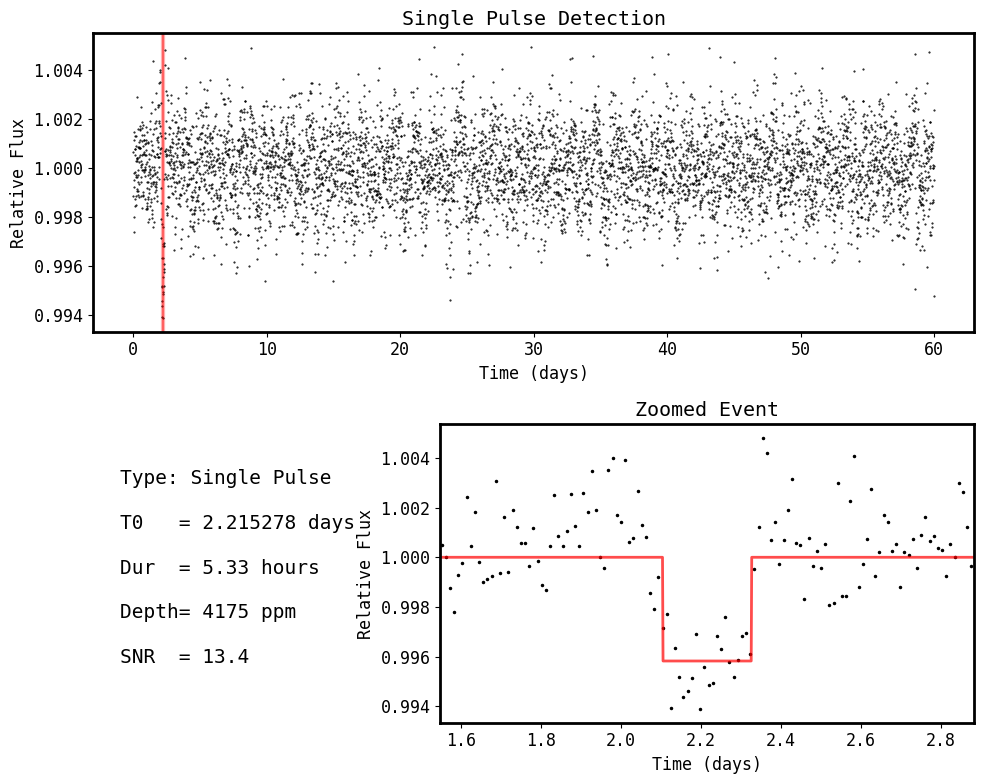

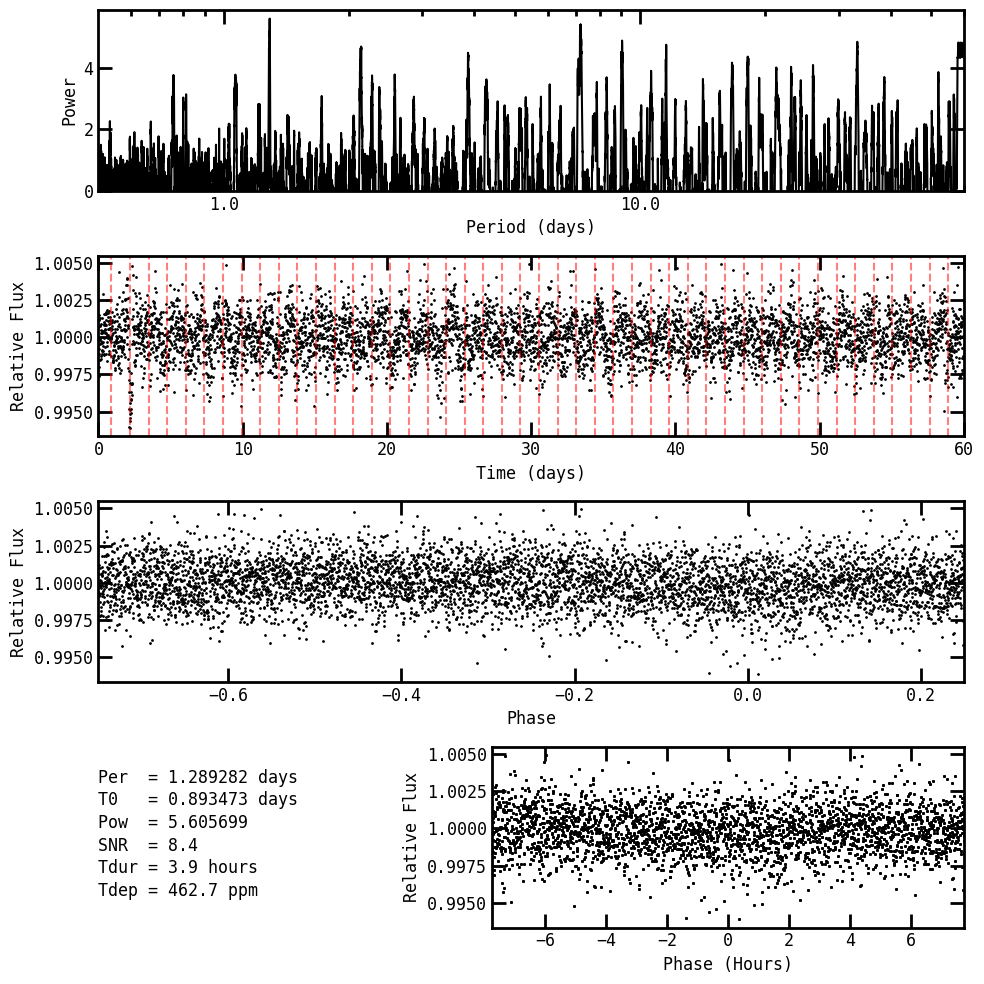

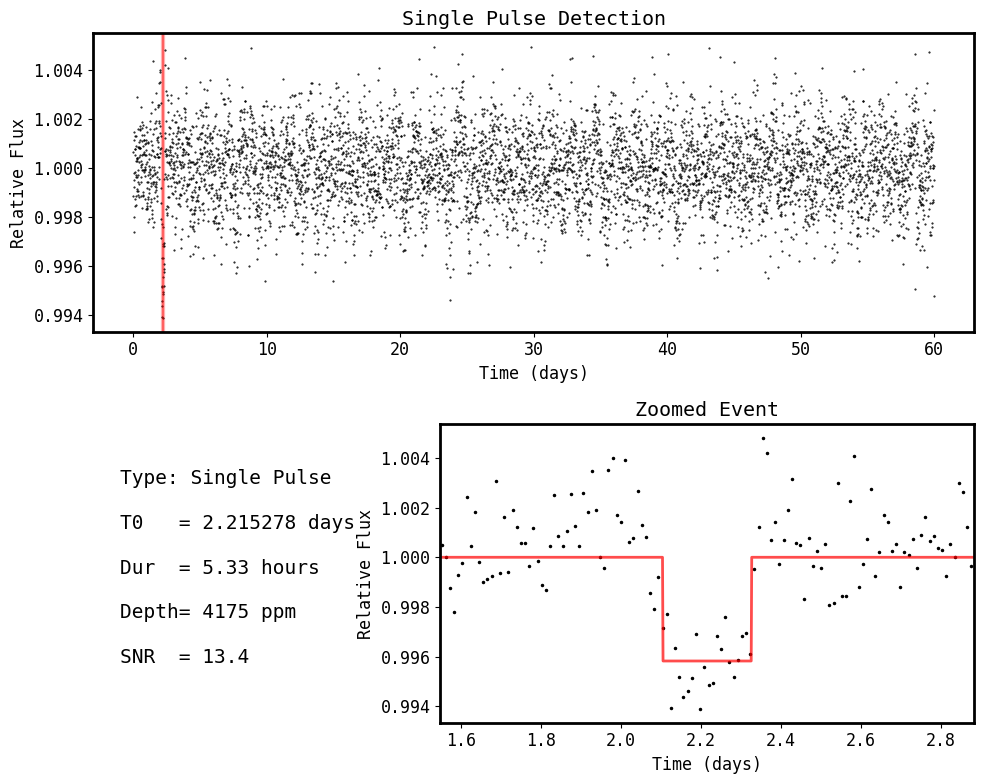

{'M_star': np.float64(1.0),
 'M_star_max': np.float64(1.2),
 'M_star_min': np.float64(0.19999999999999996),
 'R_star': np.float64(1.0),
 'R_star_max': np.float64(1.2),
 'R_star_min': np.float64(0.19999999999999996),
 'n_transits_min': 1,
 'period_min': 0.5,
 'u': [0.4804, 0.1867]}
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 48 durations
Searching 5760 data points, 6636 periods from 0.601 to 59.99 days
Using all 20 CPU threads


100%|██████████| 6636/6636 periods | 00:14<00:00
/home/sliu/bls_cuda/pytfit5/tls/transitleastsquares/main.py:205: UserWarning: No transit were fit. Try smaller "transit_depth_min"
  warnings.warn('No transit were fit. Try smaller "transit_depth_min"')


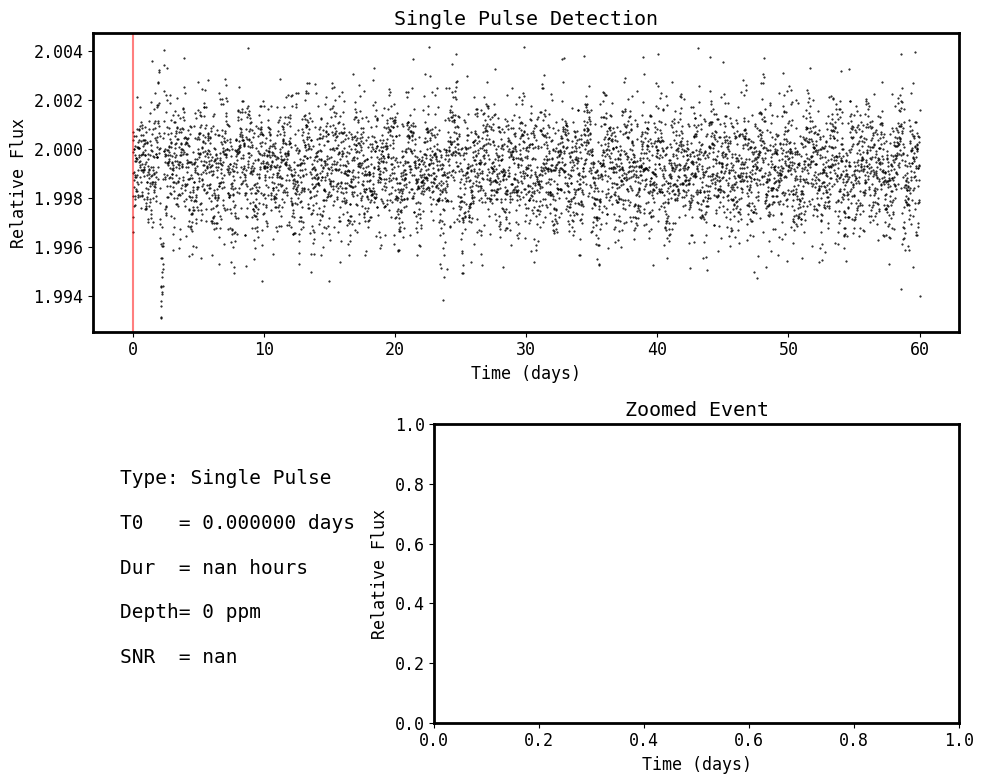

In [42]:
# Only the period is changed from the pytfit5 notebook - 10 days longer.
phot_syn, sol_injected = generate_synthetic_lightcurve(
    t0=2.2, per=66.05, time_length=60.0, depth=0.005, \
    snr=20.0, cadence=1.0/96.0, stellar_noise_type='multi', \
    stellar_noise_amplitude=0.005, rotation_period=None, seed=42)

# Configuring BLS and TLS for the synthetic data
# Removing those which are set by default appropriately, e.g zerotime, stellar parameters, etc.
syn_inputs = tpy5.tpy5_inputs_class()
syn_inputs.freq1 = 1.0 / (np.max(phot_syn.time) - np.min(phot_syn.time))  # longest period = baseline
syn_inputs.freq2 = 2.0  # c/d
syn_inputs.filename = "BLS_Synthetic"
# Data-processing is changed to 3 days detrending instead of the usual two.
syn_inputs.boxbin = 3.0  # set detrending length
syn_inputs.search_verbose  = True # for tls to spit out its parameters and search info
tpy5.run_polyfilter_iterative(phot_syn, syn_inputs)   # flux_f will contain filtered photometry

# Run Combined BLS + Pulse Search
bpulsyn = bls_pulse(syn_inputs, phot_syn.time, phot_syn.flux_f)
bpersyn = bls_periodic(syn_inputs, phot_syn.time, phot_syn.flux_f)#
bsyn = bls(syn_inputs, phot_syn.time, phot_syn.flux_f)
# Run TLS for a comparison to BLS
tsyn = tls(syn_inputs, phot_syn.time, phot_syn.flux_f)

{'M_star': np.float64(1.0),
 'M_star_max': np.float64(1.2),
 'M_star_min': np.float64(0.19999999999999996),
 'R_star': np.float64(1.0),
 'R_star_max': np.float64(1.2),
 'R_star_min': np.float64(0.19999999999999996),
 'n_transits_min': 1,
 'period_min': 0.5,
 'u': [0.4804, 0.1867]}
Transit Least Squares TLS 1.32 (5 Apr 2024)
Creating model cache for 48 durations
Searching 5760 data points, 6636 periods from 0.601 to 59.99 days
Using all 20 CPU threads


100%|██████████| 6636/6636 periods | 00:12<00:00


Searching for best T0 for period 16.04429 days


100%|██████████| 5760/5760 [00:01<00:00, 5211.37it/s]


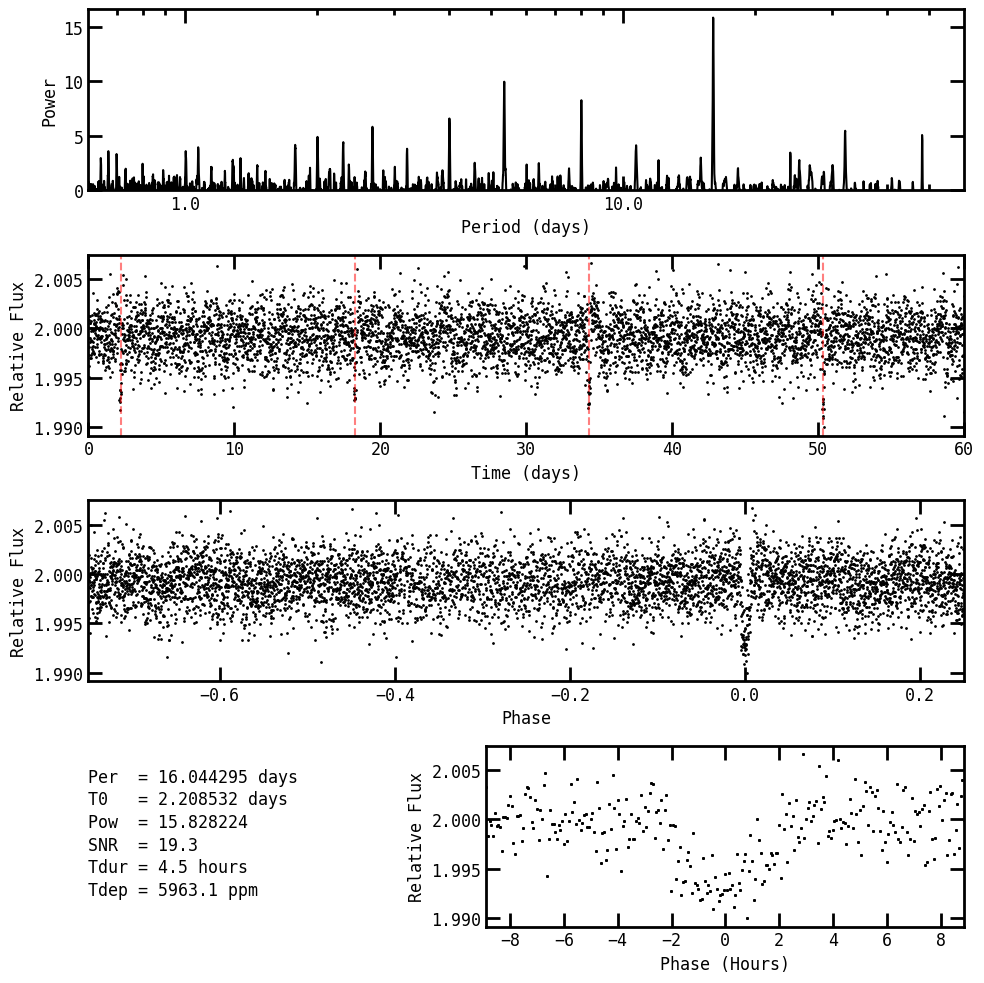

In [32]:
# Changing the period to shorter for easier detection by TLS.
phot_syn, sol_injected = generate_synthetic_lightcurve(
    t0=2.2, per=16.05, time_length=60.0, depth=0.005, \
    snr=20.0, cadence=1.0/96.0, stellar_noise_type='multi', \
    stellar_noise_amplitude=0.005, rotation_period=None, seed=42)
tpy5.run_polyfilter_iterative(phot_syn, syn_inputs)
tsyn = tls(syn_inputs, phot_syn.time, phot_syn.flux_f, phot_syn.ferr)

In [82]:
import sys
from pathlib import Path
homedir = os.getcwd()
datadir = lambda file: f'/home/sliu/digitalliance/data/{file}'

import h5py
import copy
import timeit
import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.insert(0, f'{homedir}')
import pytfit5.bls_cpu_testing as gbls
import pytfit5.transitPy5 as tpy5
import pytfit5.transitmodel as transitm
from pytfit5.synthetic import compare_bls_injection


## CONSTANTS
ROMANOFF = 2461450
SAVEDIR = f'{homedir}/data/output'
LCDIR = datadir('rlc')
COLS = np.array(['RIC', 'Period', 'T0', 'TDur', 'TDepth', \
                 'RawPer', 'SR', 'Power', 'SNR', 'Time'])
RECCOLS = ['overlap_fraction', 'precision', 'true_positive', \
          'false_positive', 'false_negative', 'period_factor', \
          'period_factor_type', 'is_recovered']
starID = np.loadtxt(datadir('stID.txt')).astype(int)
cat = pd.read_csv(datadir('trunccat.csv')) # trimmed planet catalogue!

# inherit from this class, so we can not deal with compatability issues and just put this into our functionalities?
class pipelineIns(tpy5.tpy5_inputs_class):

    def __init__(self):
        super().__init__() 
        self.rics = starID
        self.df = cat
        self.blsfunc = gbls.bls
        self.tlsfunc = gbls.tls
        self.single = False
        self.tbuff = 0.25
        self.bbuff = 0.05
        self.saveIt = 150
        self.savedir, self.lcdir = self.t5Compat()
        
    def t5Compat(self):
        '''
        Changing the directionaries so that we save it to the correct directionaries
        and also configuring the lcdir so that it points to an absolute path.
        '''
        # Configure the save mechanism and the light-curve directory.
        if not self.lcdir:
            self.lcdir = LCDIR
        if not self.savedir:
            self.savedir = lambda method, num: f'{SAVEDIR}/{self.filename}{method}{num}.csv'
            
        if isinstance(self.savedir, str): # Ensuring nothing will go wrong with saving.
            savedir = self.savedir.strip('/')
            self.savedir = lambda file: f'/{savedir}/{file}'
        return self.savedir, self.lcdir

def read2Phot(filepath, phot=None):
    '''
    Load in the data from the saved directory as defined by lcDir.
    And then, read the data into the phot class bc this is the format
    required to run the data processing functions.
    '''
    if phot == None:
        # Initialising the photometry class required for data-processing.
        phot = tpy5.phot_class()
        # Load in our time, flux, error arrays from the h5 file. 
        with h5py.File(filepath, 'r') as file:
            phot.time = file['time'][:]
            phot.flux = file['flux'][:]
            phot.ferr = file['ferr'][:]
            
    npt = len(phot.time)
    # Parameters required to store the processing arrays in.
    phot.itime = np.ones(npt) * 0.00063333 # Convert from seconds to days 
    phot.qflag = np.ones(npt)
    phot.tflag = np.zeros(npt)  # Flag for in-transit data
    phot.icut  = np.zeros(npt)  # Flat for data cuts
    
    return phot

def processData(phot, tpy5_inputs):
    '''
    Running the data-processing. Note that the detrending will always happen
    but the clipping is optional based on the previously assigned sigma-clipping.
    '''
    tpy5.run_polyfilter_iterative(phot, tpy5_inputs) # data-processing
    if tpy5_inputs.dsigclip != 0:  # data (sigma) clipping, phot.icut will flag bad data
        tpy5.run_cutoutliers(phot, tpy5_inputs)
    return (phot.icut == 0) & (phot.tflag == 0)

def getRICRow(ric, df):
    '''
    For a given star id (or roman id), we find the number of entries.
    '''
    mask = np.isin(df.star_id, ric)
    ricIdx = np.where(mask)[0][0]
    # take one row for clarity as all stellar parameters are the same.
    ricDF = df.iloc[ricIdx]
        
    return df.iloc[ricIdx]

def getROIRow(roi, df):
    '''
    Getting the roi row, which works because we only expect one row for
    each ROI.
    '''
    roidf = df[df.planet_id == roi]
    return roidf.iloc[0]

def prepInputs(ric, t5puts):
    '''
    Loading in the photometric data and data processing.
    '''
    phot = read2Phot(f'{t5puts.lcdir}/{int(ric)}/raw.h5') # getting the photometric data
    m = processData(phot, t5puts) # detrending/clipping
    ## The stellar parameters which are unique to each RIC.
    starRow = getRICRow(ric, t5puts.df)
    t5puts.rstar = float(starRow['star_radius'])
    t5puts.mstar = float(starRow['star_mass'])
    t5puts.u = starRow[['transit_limb1_F146', 'transit_limb2_F146']].values

    return t5puts, phot.time[m], phot.flux_f[m], phot.ferr[m]

# To be able to swiss-cheese in the loop function.
getPhase1 = lambda time, stats: (time - stats[1])/stats[0]
def getTransArr(time, stats, buff=0.2):
    '''
    Where the planet should be transiting, the transiting array indicates
    this with a 1.0. If it is not transiting, then transiting is 0.0.
    '''
    transiting = np.zeros(len(time))
    phase1 = getPhase1(time, stats)
    phase = phase1 - np.floor(phase1)
    phase[phase > 0.5] -= 1.0
    phase[phase < -0.5] += 1.0
    transThres = (stats[2]/stats[0]/2.0) * (1+buff)
    transMask = np.logical_and(phase < transThres, phase > -transThres)
    transiting[transMask] = 1.0

    return transiting

def swissCheese(t, f, stats, buff):
    '''
    Getting the data swiss-cheesed with the statistics of:
    period, t0 (centre of transit) and the transit duration!
    '''
    t0 = t-ROMANOFF 
    mask = getTransArr(t0, stats, buff=buff)
    return ~np.array(mask).astype(bool)

def singleIt(t5puts, t, f, err, func):
    '''
    Running a single iteration
    '''
    t1 = timeit.default_timer()
    ansob = func(t5puts, t, f, err)
    t2 = timeit.default_timer()
    stats = np.array([ansob.bper, ansob.epo, ansob.tdur, ansob.depth, \
                      ansob.rawper, ansob.SR, ansob.bpower, ansob.snr])
    return stats, t2-t1

def loop(t5puts, t, f, err, func, buff):
    '''
    Controls the while loop of tls or bls and returns an array of all the values.
    We get the stellar parameters 
    '''

    ricRun = [] # Unknown length as we begin
    # run one iteration first, and then break if we only need to run once.
    stats, tdiff = singleIt(t5puts, t, f, err, func)
    ricRun.append(np.append(stats, tdiff))
    if t5puts.single: # Do we loop or do we not?
        return np.array(ricRun)

    it = 1
    # Looping until we do not see a signal or the baseline of 10.
    while np.abs(stats[-1]) > 6 and it < 10:
        # Require the time, the flux and the error be trimmed.
        scm = swissCheese(t, f, stats[:3], buff=buff)
        t, f, err = t[scm], f[scm], err[scm]
        stats, tdiff = singleIt(t5puts, t, f, err, func)
        ricRun.append(np.append(stats, tdiff))
        it += 1

    return np.array(ricRun)

def writedf(ric, arr):
    '''
    Writing the ric run output into a dataframe. This is appended to the frames list
    and all these dataframes are then all put together.
    '''
    stdata = np.tile([int(ric)], (len(arr), 1))
    data = np.append(stdata, arr, axis=1)
    return pd.DataFrame(columns=COLS, data=data)

def save2csv(savename, frame):
    '''
    If the frame is empty, then we simply return it. If it is not, then we concat all
    the specific ric runs and save everything together. 
    '''
    if not frame: return frame 
    df = pd.concat(frame, ignore_index=True)
    df.to_csv(savename, index=False)
    return []

def main(t5puts):
    '''
    Note that t5puts are the pipeline inputs which inherits
    from tpy5_input_class. 
    '''
    tlsFrames, blsFrames = [], []
    saveNum = 0
    
    for i, ric in enumerate(t5puts.rics):
        print(f'Starting RIC: {ric}, which is number: {i}!')
        t5puts, t, f, err = prepInputs(ric, t5puts)

        if t5puts.tlsfunc is not None:
            tarr = loop(t5puts, np.copy(t), np.copy(f), np.copy(err), t5puts.tlsfunc, t5puts.tbuff)
            tlsFrames.append(writedf(ric, tarr))
    
        if t5puts.blsfunc is not None:
            barr = loop(t5puts, np.copy(t), np.copy(f), np.copy(err), t5puts.blsfunc, t5puts.bbuff)
            blsFrames.append(writedf(ric, barr))

        ## Saving if necessary!
        if max(len(tlsFrames), len(blsFrames)) >= t5puts.saveIt:
            # Checking with max because len(tlsFrame) == len(blsFrame) if both are run
            print(f'This is save no. {saveNum}.')
            tlsFrames = save2csv(t5puts.savedir('tls', saveNum), tlsFrames)
            blsFrames = save2csv(t5puts.savedir('bls', saveNum), blsFrames)
            saveNum += 1 # resetting the frames to zero so increment count.

    # To account for the last save if it is not a round number          
    print(f'Finished! Saving (just in case) again.')
    tlsFrames = save2csv(t5puts.savedir('tls', saveNum), tlsFrames)
    blsFrames = save2csv(t5puts.savedir('bls', saveNum), blsFrames)

## PLOTTING FUNCTIONALITIES
def plotSpecs(ax, logscale):
    '''
    Specifications for the tick parameters and for the logscale.
    logscale: can be an integer or a list.
    '''
    ax.tick_params(direction='in', which='major', bottom=True, top=True, \
                   left=True, right=True, length=10, width=2)
    ax.tick_params(direction='in', which='minor', bottom=True, top=True,  \
                   left=True, right=True, length=4, width=2)

    if logscale==1:
        ax.set_xscale('log')
        ax.set_yscale('log')
    elif logscale==2:
        ax.set_xscale('log')
    elif logscale==3:
        ax.set_yscale('log')
        
    return ax
    
def setupPlot(sizeTuple, logscale=1, fontsize=16, scalar=True):
    '''
    To format single plots uniformly. The sizeTuple is a tuple.
    logscale: should be an integer if trying to get axis in logscale.
    scalar: allows us to format the x and y axis as scalars.
    '''
    matplotlib.rcParams.update({'font.size': fontsize}) #adjust font
    matplotlib.rcParams['axes.linewidth'] = 2.0
    
    fig = plt.figure(figsize=sizeTuple) #adjust size of figure
    ax = plt.axes()
    ax = plotSpecs(ax, logscale)

    if scalar:
        ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
        ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    
    return fig,ax

def setupPlots(sizeTuple, row=1, col=2, logscale=1, fontsize=16, scalar=True, **kwargs):
    '''
    Uses the same style as setupPlot but allows for multiple plots.
    logscale can be an integer or it can be an iterable, i.e. list.
    scalar: allows us to format the x and y axis as scalars.
    '''
    
    matplotlib.rcParams.update({'font.size': fontsize}) # adjust font
    matplotlib.rcParams['axes.linewidth'] = 2.0

    # If all the plots should be on the same scale, then the user can input an integer.
    if isinstance(logscale, int):
        logscale = np.repeat(logscale, row*col)
    
    fig, axs = plt.subplots(nrows=row, ncols=col, figsize=sizeTuple, **kwargs) # adjust size of figure
    for i, ax in enumerate(axs.flatten()):
        ax = plotSpecs(ax, logscale[i])
        if scalar:
            ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
            ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
    
    return fig, axs

def rho(mass, radius):
    '''
    Getting the density parameter!
    '''
    radius_cm = radius*gbls.Rsun*100
    mass_g = mass*gbls.Msun*10**3
    return mass_g / (4/3 * np.pi * radius_cm**3)

def getROIRow(roi, df):
    '''
    Getting the row of values for the specified ROI.
    (works because we only expect one row for each ROI)
    '''
    roidf = df[df.planet_id == roi]
    return roidf.iloc[0]

def makesol(roirow):
    '''
    Formatting the dataframe information into a class, so it 
    can be brought into the function accordingly.
    ''' 
    if 'star_rho' not in roirow.index:
        roirow['star_rho'] = rho(roirow.star_mass, roirow.star_radius)
        
    solr = transitm.transit_model_class()
    solr.npl = 1.0
    solr.t0 = [roirow.transit_t0_BRJD + (0.5 - 105)]
    solr.per = [roirow.transit_period]
    solr.rdr = [roirow.transit_rp_rstar]
    solr.bb = [roirow.planet_impact]
    solr.rho = roirow.star_rho

    return solr

def roirec(roirow, rundf, rlcdir=None):
    '''
    For each ROI, we must iterate through all the runs for that specific RIC.
    '''
    roirow = roirow.iloc[0]
    roi = float(roirow.planet_id)
    
    ricrundf = rundf[np.isin(rundf.RIC, int(roi))]
    recdf = pd.DataFrame(columns=RECCOLS)
    # The solution and time array are constant for all runs.
    roisol = makesol(roirow)
    if rlcdir == None:
        rlcdir = f'{LCDIR}/{int(roi)}raw.h5'
    phot = read2Phot(rlcdir)
    phot.time = phot.time - ROMANOFF

    for runrow in ricrundf.itertuples():
        runsol = copy.deepcopy(roisol)
        runsol.t0 = [runrow.T0]
        runsol.per = [runrow.Period]
        runsol.rdr = [np.sqrt(runrow.TDepth)]
        runrec = compare_bls_injection(phot, sol_injected=roisol,\
                sol_bls=runsol, verbose=False)
        # This unpacks easily because runrec is in a dictionary form.
        recdf.loc[len(recdf)] = runrec

    # Convert the index from ricrundf to the recovery dataframe.
    recdf.set_index(ricrundf.index, inplace=True)
    m = np.array(recdf.period_factor_type != 'mismatch')
    if bool(np.sum(m)):
        adddf = ricrundf.loc[m, ['Period', 'T0', 'TDur', 'TDepth', 'SNR']]
        dfs = pd.concat([adddf, recdf[m]], axis=1)
        return dfs

def pulseRICs(bdf):
    '''
    If the raw period of BLS is zero, then we know the pulse signal strength
    has 'won' over the periodic signal strength. Therefore, we look for cases
    where all the runs for a certain ric have raw power of zero.
    '''
    rics, counts = np.unique(bdf.RIC, return_counts=True)
    # Count the number of runs per RIC
    rics0, counts0 = np.unique(bdf.RIC[bdf.RawPer == 0], return_counts=True)
    # Count the number of pulse runs
    pulsem = np.isin(rics, rics0)
    # If a RIC only has pulse runs then a periodic signal was never searched for.
    return rics0[counts[pulsem] == counts0]

def persnr(rois, cat):
    '''
    Getting the period and SNR from the catalogue!
    Mainly for plotting purposes.
    '''
    m = np.isin(cat.planet_id, rois)
    return cat.transit_period[m], cat.planet_transit_snr[m]

# Primarily used for the histogram of the recovery statistic.
def getLims(arr):
    '''
    To return where the bins should begin by the minimum value
    and where the bin range should end by the maximum value.
    '''
    return np.min(arr), np.max(arr)

def logBins(dMin, dMax, binNum):
    '''
    Return the bin edges in logarithmic intervals. 
    '''
    return np.logspace(np.log10(dMin), np.log10(dMax), binNum+1)

def linBins(dMin, dMax, binNum):
    '''
    Return the bin edges in linear intervals. 
    '''
    return np.linspace(dMin, dMax, binNum+1)

# Constructing and running the histogram plotting functionalities. 
def getHist(data, binNum, log, xMin=0, xMax=0):
    '''
    Obtain the histogram and the bin edges. Can be used for both logarithmic and linear plots. 
    '''

    if xMin == xMax:
        xMin, xMax = getLims(data[~np.isnan(data)])
    if log:
        binE = logBins(xMin, xMax, binNum)
    else:
        binE = linBins(xMin, xMax, binNum)
    
    return np.histogram(data, bins=binE)

def stepFul(h, x):
    '''
    So the step function begins at zero instead of starting midair.
    '''
    return np.append(np.array([0]), h), np.append(np.array([0]), x)

def zeroB(x):
    '''
    To ensure the zero bin is not overly large and allows the x array to increase in order.
    '''
    if x[0] < x[1]-x[0]:
        return x[0]
    return x[1]-x[0]

def histPlot(bData, tData, ax, labels=['TLS', 'TLS Mod'], binNum=25, log=True, rec=True):
    '''
    Allows for common formatting of the histogram. 
    '''
    if rec:
        tH, tX = getHist(tData[tData > 0], binNum, log)
        # bH, bX = np.histogram(bData[bData > 0], bins=tX)
        bH, bX = getHist(bData[bData > 0], binNum, log)
        
        tX = np.append([0, zeroB(tX)], tX)
        tH = np.append([len(tData[tData <= 0]), 0], tH)
        bX = np.append([0, zeroB(bX)], bX)
        bH = np.append([len(bData[bData <= 0]), 0], bH)
    else:
        tH, tX = getHist(tData, binNum, log)
        bH, bX = np.histogram(bData, bins=tX)
        
    ax.hist(tX[:-1], tX, weights=tH, alpha=0.3, color='orange')
    ax.hist(bX[:-1], bX, weights=bH, edgecolor='white', alpha=0.8, label=labels[0])
    tH, tX = stepFul(tH, tX)
    ax.step(tX, np.append(tH, np.array([0])), where='post', linewidth=3, label=labels[1])

    ax.grid(True, linestyle='--', alpha=0.75)
    ax.set_ylabel('Frequency')
    ax.legend()

    return ax

Starting RIC: 4529960, which is number: 0!


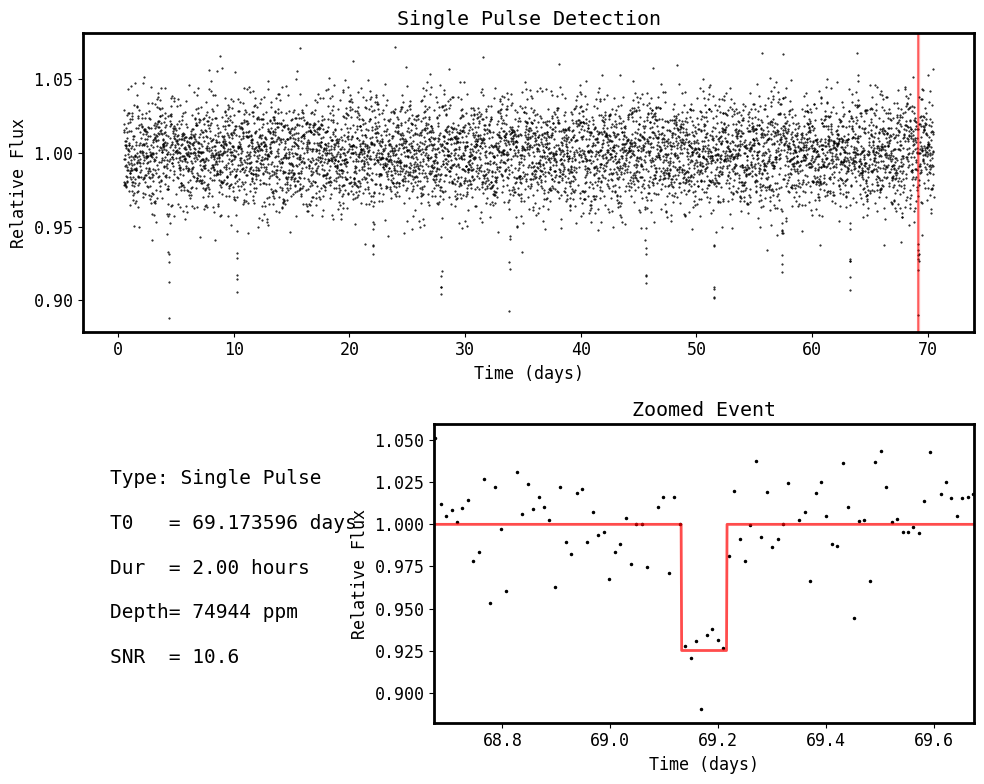

Starting RIC: 4577981, which is number: 1!


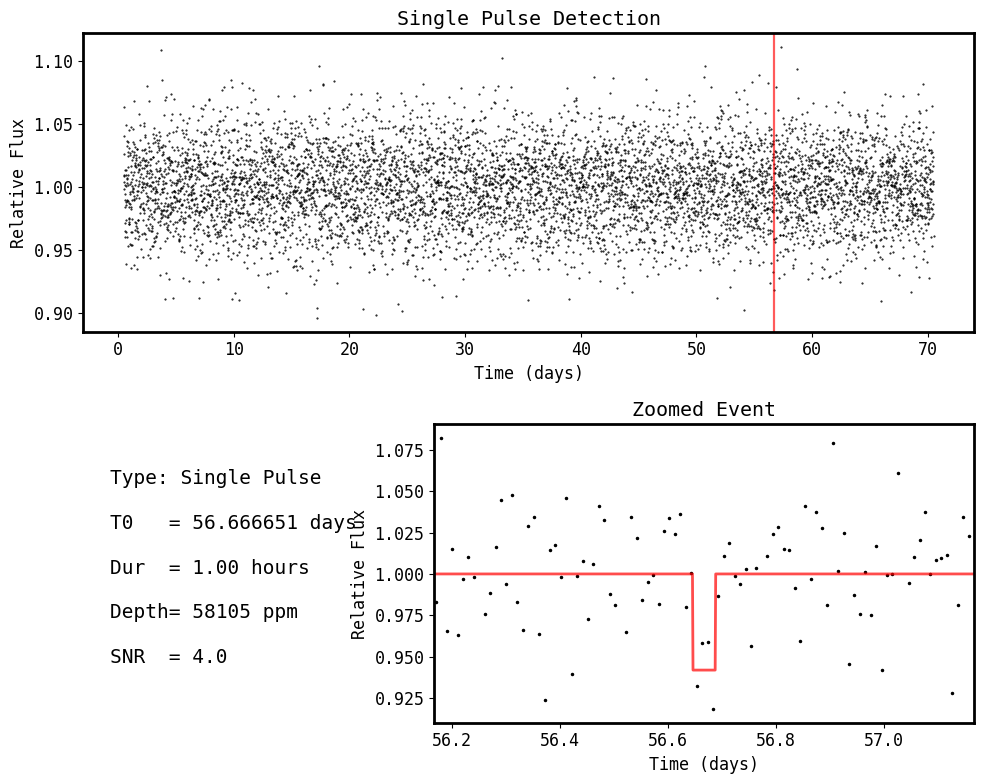

Starting RIC: 4623087, which is number: 2!


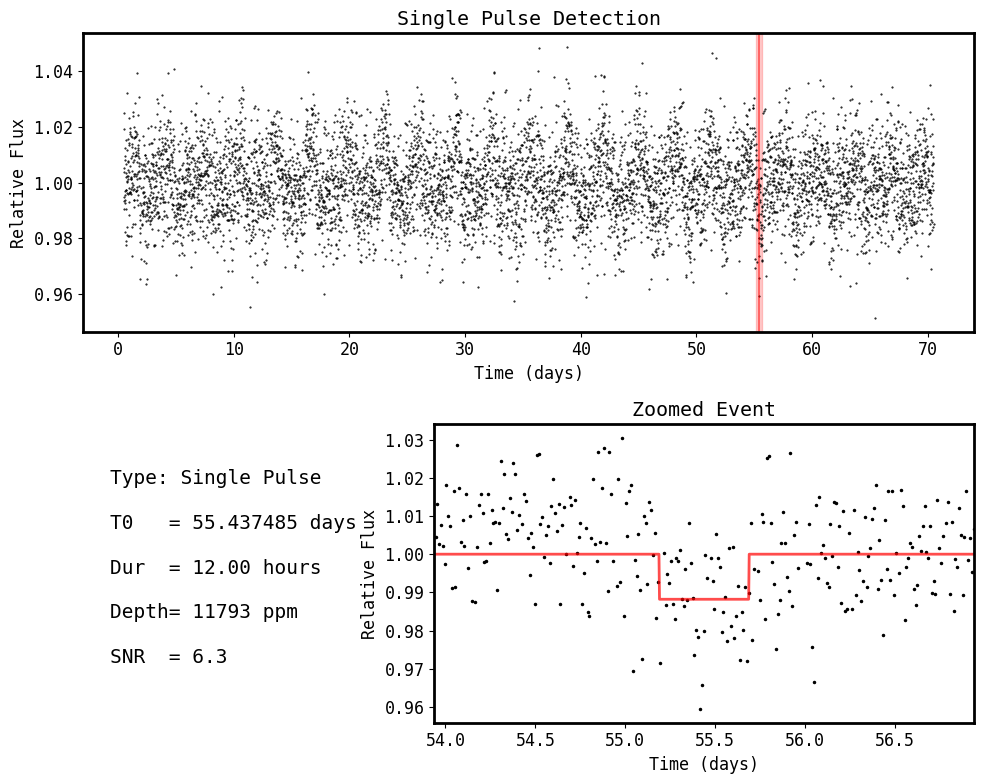

Starting RIC: 466905, which is number: 3!


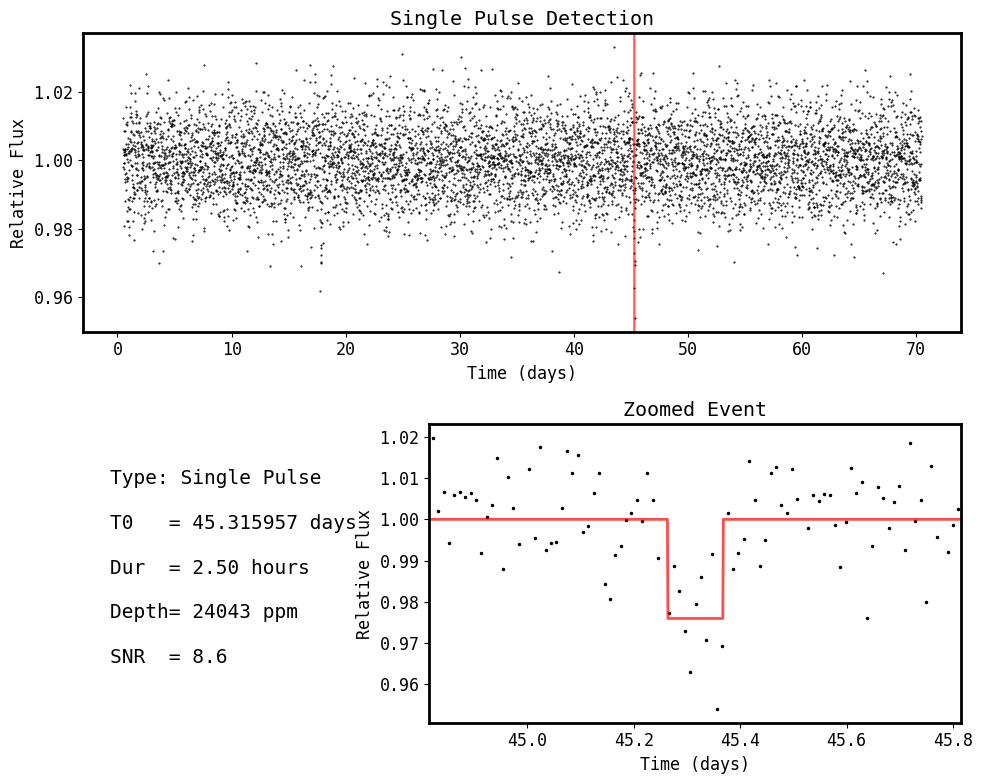

Finished! Saving (just in case) again.


In [83]:
piput = pipelineIns()
piput.zerotime = ROMANOFF
piput.boxbin, piput.dsigclip = 3.0, 0
piput.filename = 'check'
piput.rics = [4529960, 4577981, 4623087, 466905]
piput.tlsfunc = None
# piput.plots = 0
piput.blsfunc = bls_pulse
piput.single = True
main(piput)